<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_10_svm.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BYU CS 473 — Support Vector Machines

In this assignment, you will explore Support Vector Machines. You will train an SVM on a 2-class, 2-feature subset of the Iris dataset to visualize decision boundaries and compare its performance and characteristics to Logistic Regression. This will deepen your understanding of discriminative classifiers and margin-based decision boundaries. You will also use your SVM on a dataset of your own choice.

---

### Learning Goals
- Understand the core idea of SVMs and their margin maximization principle.  
- Train and evaluate an SVM classifier using scikit-learn.  
- Visualize decision boundaries and compare to Logistic Regression.  
- Reflect on the strengths and weaknesses of SVMs versus Logistic Regression.

### Grading Standards

| Component                                 | Weight |
|------------------------------------------|--------|
| Data loading & preprocessing              | 10%    |
| SVM training & prediction (using sklearn) | 10%    |
| SVM on a dataset of your choice | 20%    |
| Logistic Regression training & comparison | 20%    |
| Decision boundary visualizations (clear & labeled) | 20%    |
| Accuracy/time comparison + short writeup | 15%    |
| Code tidy and notebook presentation       | 5%     |

### Description & Task Flow

You will perform the following parts:

**Part 1 — Load the Iris dataset and then a dataset of your choice.**
- Search classification datasets on kaggle

**Part 2 — Train and Evaluate SVM**

- Use `sklearn.svm.SVC` with a linear kernel to train on a 2-class, 2-feature subset of Iris.  
- Measure training time and test accuracy.  
- Plot the decision boundary and support vectors.

**Part 3 — Compare to Logistic Regression**

- Train Logistic Regression on the Iris dataset.  
- Measure training time and test accuracy.  
- Plot its decision boundary for comparison.

**Part 4 — Reflection**
- Write a short reflection (3–5 sentences) comparing SVM and Logistic Regression in terms of accuracy, training time, and decision boundary characteristics.
- Write a short reflection and your results using an SVM using the dataset of your choice.

### Data

Use `sklearn.datasets.load_iris()` and select two classes (e.g., versicolor and virginica) and two features (e.g., petal length and petal width) for 2D visualization.
Find the best two suitable classes in the dataset of your own choice for comparison.



In [13]:
# ===== Iris data loading and preprocessing =====
import numpy as np
import time
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Iris and pick two classes + two features for 2D visualization
iris = load_iris()
X_all = iris['data']
y_all = iris['target']

# Choose classes 1 and 2 (versicolor, virginica) and features 2 and 3 (petal length, petal width)
mask = (y_all == 1) | (y_all == 2)
X = X_all[mask][:, 2:4]   # shape (n_samples, 2)
y = y_all[mask]
# Remap labels to {0,1}
y = (y == 2).astype(int)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("X_train:", X_train_s.shape, "y_train:", y_train.shape)


X_train: (70, 2) y_train: (70,)


In [14]:
tit_train.describe()

NameError: name 'tit_train' is not defined

In [ ]:
tit_train.corr(numeric_only = True)


### Training SVM and LR for titanic

In [ ]:
# ===== Helper plotting function=====
import matplotlib.pyplot as plt
import numpy as np

def plot_mesh_predict(model, X, y, scaler=None, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))
    X_use = X if scaler is None else scaler.inverse_transform(X)
    x_min, x_max = X_use[:,0].min() - 1, X_use[:,0].max() + 1
    y_min, y_max = X_use[:,1].min() - 1, X_use[:,1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_in = grid if scaler is None else scaler.transform(grid)
    Z = model.predict(grid_in).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X_use[:,0], X_use[:,1], c=y, edgecolor='k')
    if title:
        ax.set_title(title)
    return ax


In [ ]:
# ===== Train and evaluate SVM =====
from sklearn.svm import SVC
import time

svm = SVC(kernel='linear')

start = time.perf_counter()
svm.fit(X_train_s, y_train)
end = time.perf_counter()

print(f"SVM training time: {end - start:.4f} seconds")
print(f"SVM test accuracy: {svm.score(X_test_s, y_test):.4f}")

ax = plot_mesh_predict(svm, X_train_s, y_train, title="SVM Decision Boundary")
# Plot support vectors
sv = svm.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=100, facecolors='none', edgecolors='r', label='Support Vectors')
ax.legend()
plt.show()

In [ ]:
print(svm.get_params)

Logistic Regression training time: 0.0047 seconds
Logistic Regression test accuracy: 0.9000


<Axes: title={'center': 'Logistic Regression Decision Boundary'}>

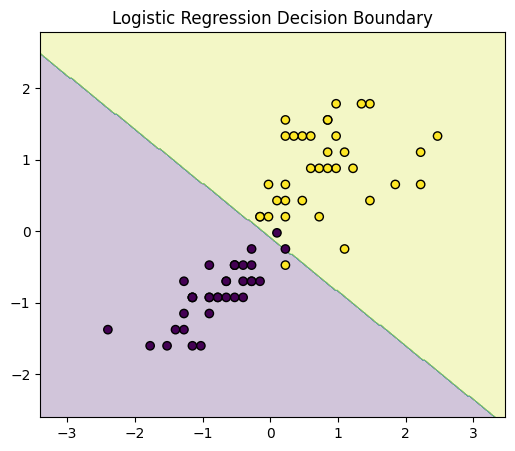

In [15]:
# ===== Train and evaluate Logistic Regression =====
from sklearn.linear_model import LogisticRegression
import time

lr = LogisticRegression()

start = time.perf_counter()
lr.fit(X_train_s, y_train)
end = time.perf_counter()

print(f"Logistic Regression training time: {end - start:.4f} seconds")
print(f"Logistic Regression test accuracy: {lr.score(X_test_s, y_test):.4f}")

plot_mesh_predict(lr, X_train_s, y_train, title="Logistic Regression Decision Boundary")


In [16]:
# ===== Calculate precision, recall and f1 to include in your analysis for both the SVM and the regression model =====
from sklearn.metrics import precision_score, recall_score, f1_score

svm_y_pred = svm.predict(X_test_s)
lr_y_pred = lr.predict(X_test_s)

#accuracy
svm_accuracy = svm.score(X_test_s, y_test)
svm_prec = precision_score(svm_y_pred, y_test)
svm_recall = recall_score(svm_y_pred, y_test)
svm_f1 = f1_score(svm_y_pred, y_test)

print(f' svm_accuracy: {svm_accuracy:.3} \n svm_precision: {svm_prec:.3} \n svm_recall: {svm_recall:.3} \n svm_f1: {svm_f1:.3}')

lr_accuracy = lr.score(X_test_s, y_test)
lr_prec = precision_score(lr_y_pred, y_test)
lr_recall = recall_score(lr_y_pred, y_test)
lr_f1 = f1_score(lr_y_pred, y_test)

print(f' lr_accuracy: {lr_accuracy:.3} \n lr_precision: {lr_prec:.3} \n lr_recall: {lr_recall:.3} \n lr_f1: {lr_f1:.3}')
print(f'\n SVM to LR ratio: \n accuracy: {svm_accuracy/lr_accuracy:.3} \n precision: {(svm_prec/lr_prec):.3} \n recall: {(svm_recall/lr_recall):.3} \n f1_score: {(svm_f1/lr_f1):.3}')



 svm_accuracy: 0.867 
 svm_precision: 0.8 
 svm_recall: 0.923 
 svm_f1: 0.857
 lr_accuracy: 0.9 
 lr_precision: 0.867 
 lr_recall: 0.929 
 lr_f1: 0.897

 SVM to LR ratio: 
 accuracy: 0.963 
 precision: 0.923 
 recall: 0.994 
 f1_score: 0.956


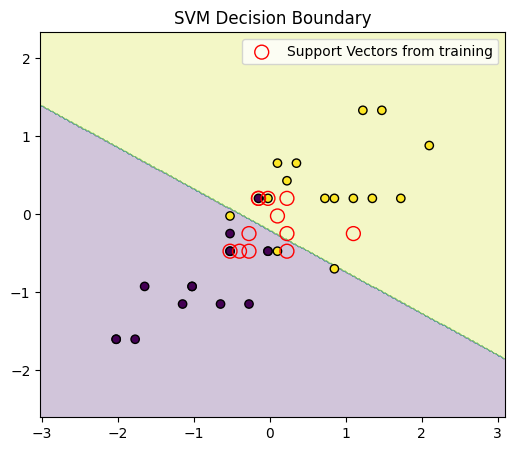

In [17]:
ax = plot_mesh_predict(svm, X_test_s, y_test, title="SVM Decision Boundary")

# Plot support vectors
sv = svm.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=100, facecolors='none', edgecolors='r', label='Support Vectors from training')
ax.legend()
plt.show()

<Axes: title={'center': 'LR Decision Boundary'}>

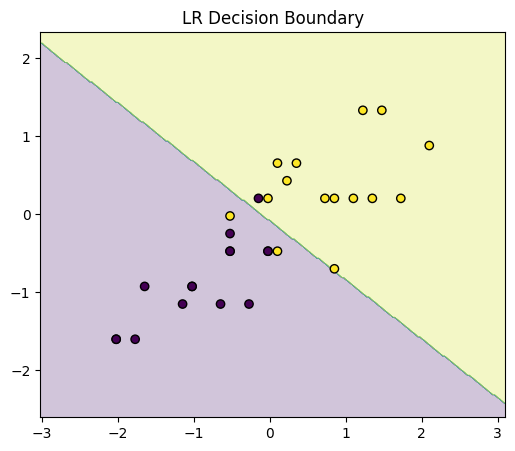

In [18]:
plot_mesh_predict(lr, X_test_s, y_test, title='LR Decision Boundary')

In [20]:
# =====  Loading and preprocessing of a dataset of your own choice=====
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#we're going to use Pclass and Fare because they have the largest correlations
# with our target variable, "survived"

#I think that this is good because they have opposite correlations and only
#only .5 correlation with each other. they could be picking up very indenependant
# information.

tit_data = pd.read_csv('train.csv')

# Select features and target from the training data
tit_X = tit_data[['Age', 'Fare']]
tit_y = tit_data['Survived']

# Handle missing values in 'Age' and 'Fare' columns by filling with the mean
tit_X.loc[:, 'Age'] = tit_X['Age'].fillna(tit_X['Age'].mean())
tit_X.loc[:, 'Fare'] = tit_X['Fare'].fillna(tit_X['Fare'].mean())

# Train/test split for the custom dataset
tit_X_train, tit_X_test, tit_y_train, tit_y_test = train_test_split(
    tit_X, tit_y, test_size=0.3, random_state=42, stratify=tit_y)

# Standardize features for the custom dataset
tit_scaler = StandardScaler().fit(tit_X_train)
tit_X_train_s = tit_scaler.transform(tit_X_train)
tit_X_test_s = tit_scaler.transform(tit_X_test)

print("tit_X_train_s:", tit_X_train_s.shape, "tit_y_train:", tit_y_train.shape)
print("tit_X_test_s:", tit_X_test_s.shape, "tit_y_test:", tit_y_test.shape)

tit_X_train_s: (623, 2) tit_y_train: (623,)
tit_X_test_s: (268, 2) tit_y_test: (268,)


In [21]:
# train the titanic dataset" SVM

svm_tit = SVC(kernel='linear')

start = time.perf_counter()
svm_tit.fit(tit_X_train_s, tit_y_train)
end = time.perf_counter()

print(f'training time: {end-start:.3f} seconds')
print(f'test accuracy: {svm_tit.score(tit_X_test_s, tit_y_test):.3f}')

training time: 0.021 seconds
test accuracy: 0.649


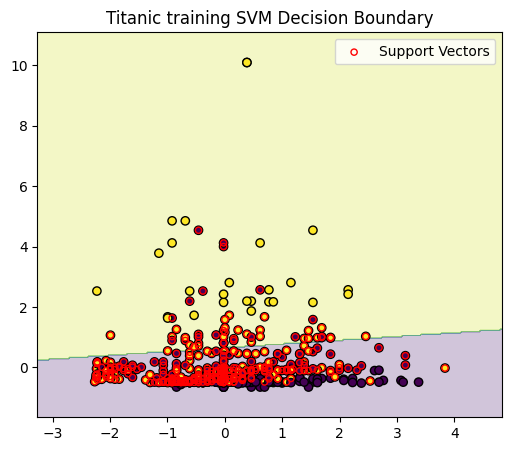

In [36]:
# ===== graph titanic SVM

ax = plot_mesh_predict(svm_tit, tit_X_train_s, tit_y_train, title="Titanic training SVM Decision Boundary")
# Plot support vectors
sv = svm_tit.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=20, facecolors='none', edgecolors='r', label='Support Vectors')
ax.legend()
plt.show()

SVM on test set:

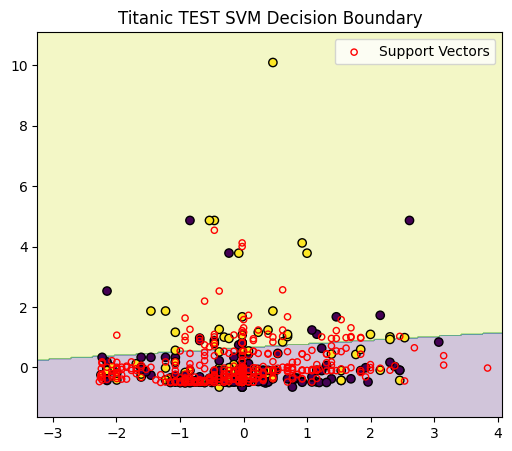

In [37]:
# ===== graph titanic SVM

ax = plot_mesh_predict(svm_tit, tit_X_test_s, tit_y_test, title="Titanic TEST SVM Decision Boundary")
# Plot support vectors
sv = svm_tit.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=20, facecolors='none', edgecolors='r', label='Support Vectors')
ax.legend()
plt.show()

Now for LR on the titanic features:

In [25]:
tit_lr = LogisticRegression()

start = time.perf_counter()
tit_lr.fit(tit_X_train_s, tit_y_train)
end = time.perf_counter()

print(f'training time: {end-start:.3f} seconds')

training time: 0.007 seconds


LR on training set

<Axes: title={'center': 'Titanic training LR Decision Boundary'}>

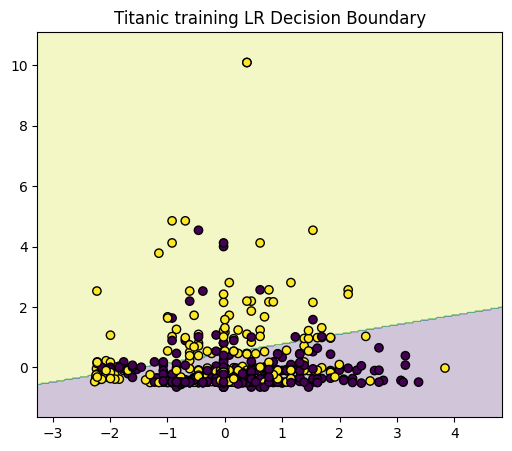

In [31]:
plot_mesh_predict(tit_lr, tit_X_train_s, tit_y_train, title='Titanic training LR Decision Boundary')

LR on test set:

<Axes: title={'center': 'Titanic test set LR Decision Boundary'}>

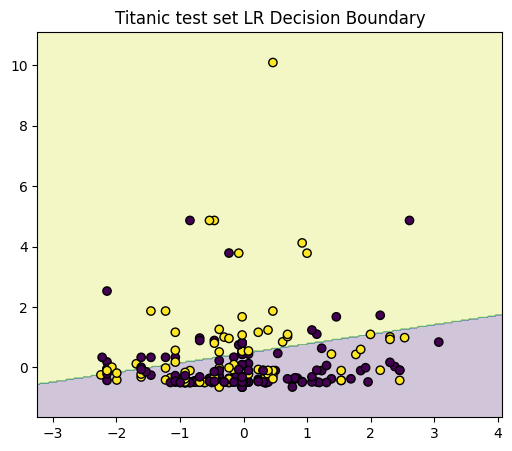

In [32]:
# running on test set and graphing

plot_mesh_predict(tit_lr, tit_X_test_s, tit_y_test, title='Titanic test set LR Decision Boundary')
# print(f'test accuracy: {tit_lr.score(tit_y_test)}'


###General scoring on the test set:

In [39]:
# ===== Calculate precision, recall and f1 to include in your analysis for both the SVM and the regression model =====
from sklearn.metrics import precision_score, recall_score, f1_score

tit_svm_y_pred = svm_tit.predict(tit_X_test_s)
tit_lr_y_pred = tit_lr.predict(tit_X_test_s)

#accuracy
tit_svm_accuracy = svm.score(tit_X_test_s, tit_y_test)
tit_svm_prec = precision_score(tit_svm_y_pred, tit_y_test)
tit_svm_recall = recall_score(tit_svm_y_pred, tit_y_test)
tit_svm_f1 = f1_score(tit_svm_y_pred, tit_y_test)

print(f' svm_accuracy: {tit_svm_accuracy:.3} \n svm_precision: {tit_svm_prec:.3} \n svm_recall: {tit_svm_recall:.3} \n svm_f1: {tit_svm_f1:.3}')

tit_lr_accuracy = tit_lr.score(tit_X_test_s, tit_y_test)
tit_lr_prec = precision_score(tit_lr_y_pred, tit_y_test)
tit_lr_recall = recall_score(tit_lr_y_pred, tit_y_test)
tit_lr_f1 = f1_score(tit_lr_y_pred, tit_y_test)

print(f' lr_accuracy: {tit_lr_accuracy:.3} \n lr_precision: {tit_lr_prec:.3} \n lr_recall: {tit_lr_recall:.3} \n lr_f1: {tit_lr_f1:.3}')
print(f'\n SVM to LR ratio: \n accuracy: {tit_svm_accuracy/tit_lr_accuracy:.3} \n precision: {(tit_svm_prec/tit_lr_prec):.3} \n recall: {(tit_svm_recall/tit_lr_recall):.3} \n f1_score: {(tit_svm_f1/tit_lr_f1):.3}')



 svm_accuracy: 0.616 
 svm_precision: 0.243 
 svm_recall: 0.61 
 svm_f1: 0.347
 lr_accuracy: 0.631 
 lr_precision: 0.301 
 lr_recall: 0.534 
 lr_f1: 0.385

 SVM to LR ratio: 
 accuracy: 0.976 
 precision: 0.806 
 recall: 1.14 
 f1_score: 0.902


Write 3–5 sentences comparing SVM and Logistic Regression in terms of:

Accuracy

Precision

Recall

F1

Training time

Decision boundary shape and margin properties





### for iris dataset:


 In terms of every scoring metric that I used, LR was superior slightly. What's interesting is that SVM allows points to be on the wrong side of the boundary by doing a gradient penalty, starting at the margin closest to the same class as the points. We are also trying to maximize the margin, but logistic regression does not care how close points get to the boundary so long as they do not cross it. And along with crossing it, the penalty is calculated with a squaring function, so points very close, but on the wrong side of  the boundary have practically zero penalty.

 What we see the result of this is that we have a specific yellow test point that didn't get on the right side of the boundary in SVM. Because of this point, we see  SVM lagging behind about 90-95% in every metric. The training time, however, is not even a tenth of that of the logistic regression! We can see that SVMs may scale better in training time.

###titanic dataset:

We see, interestingly enough, that the accuracy is closer here than in the last one (for a ratio. The raw accuracy was not good because there's huge error-term endogeneity/aliatoric uncertainty in this type of dataset.), and the recall was actually much much better in SVM. I think that I see SVM had a much more conservative slope, so it was sort of making fewer assumptions about the shape of the boundary and more just putting it through the middle of the glob of points. Still, it was only able to do this because on the training set, mostly purple points are on the bottom right, but a margin penalty lets us ignore the high yellows that are on the right and lower the slope. In all honesty, LR is still probably better here because the f1 score and accuracy were higher, but it is still insightful to observe the differences between the two.

# Extra credit (5%)

In [ ]:
# ===== Train and evaluate Logistic Regression =====

class LinearSVM:
    def __init__(self, learning_rate=0.01, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        # TODO: implement gradient descent to optimize hinge loss
        pass

    def predict(self, X):
        # TODO: implement prediction based on learned weights
        pass

In [ ]:
# ===== Calculate the accuracy of the iris dataset using both your SVM and the Sklearn SVM =====
from sklearn.svm import SVC

In [ ]:
# ===== Now calculate the accuracy of your own dataset using both methods=====
from sklearn.svm import SVC

In 3-5 sentences describe your results for both datasets